In [24]:
import pandas as pd

In [25]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# TCGA

In [ ]:
#TCGA Breast Cancer gene-expression metrics
path = "/content/drive/MyDrive/ECEN766final/HiSeqV2"

expr = pd.read_csv(path, sep="\t", index_col=0)
#print(expr.shape)

# transpose to rows:patients/cols:genes
expr = expr.T
print(expr.shape)

(1218, 20530)


In [ ]:
expr.head()

sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
TCGA-3C-AAAU,10.4713,2.3606,0.0000,11.6317,11.2053,10.1911,12.3502,4.0452,0.7564,7.6254,...,0.0000,2.1527,3.7074,0.0000,8.9560,11.4006,7.8250,12.1997,5.6018,9.7282
TCGA-3C-AALI,9.2228,0.6265,0.6265,11.8757,10.4259,10.1674,12.4482,4.1138,2.2650,6.7420,...,1.0618,1.6668,4.9499,3.2780,9.3888,12.1666,8.1093,10.7031,5.5942,10.0766
TCGA-3C-AALJ,10.9468,0.9310,0.0000,12.2616,10.7842,9.5713,12.7540,4.9504,0.0000,5.2197,...,0.0000,0.9310,4.2579,1.4922,9.3284,12.5534,8.7597,12.0469,5.6941,10.1682
TCGA-3C-AALK,9.9856,2.6732,0.0000,11.9567,11.0071,10.0354,12.6732,5.0382,0.0000,5.5899,...,1.1643,1.4087,4.2634,0.0000,9.3354,13.0257,7.9614,11.3719,8.6253,10.2333
TCGA-4H-AAAK,10.2842,2.2720,0.0000,11.7566,10.8499,9.9325,12.3191,3.1835,0.8884,6.1192,...,1.4341,0.8884,3.9904,0.0000,9.0038,13.1156,7.6902,10.8298,5.7256,10.0402


In [ ]:
# Load TCGA Breast Cancer survival data
surv_path = "/content/drive/MyDrive/ECEN766final/survival_BRCA_survival.txt"

surv = pd.read_csv(surv_path, sep="\t")
print(surv.shape)
surv.head()

(1236, 11)


,sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,0,4047.0,0.0,4047.0,1.0,1808.0,1,1808.0,NaN
1,TCGA-3C-AALI-01,TCGA-3C-AALI,0,4005.0,0.0,4005.0,0.0,4005.0,0,4005.0,NaN
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,0,1474.0,0.0,1474.0,0.0,1474.0,0,1474.0,NaN
3,TCGA-3C-AALK-01,TCGA-3C-AALK,0,1448.0,0.0,1448.0,NaN,NaN,0,1448.0,NaN
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,0,348.0,0.0,348.0,0.0,348.0,0,348.0,NaN


In [ ]:
surv = surv[["_PATIENT", "OS.time", "OS"]]
surv = surv.dropna()
surv.head()

,_PATIENT,OS.time,OS
0,TCGA-3C-AAAU,4047.0,0
1,TCGA-3C-AALI,4005.0,0
2,TCGA-3C-AALJ,1474.0,0
3,TCGA-3C-AALK,1448.0,0
4,TCGA-4H-AAAK,348.0,0


In [ ]:
expr.index[:5]

Index(['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01',
       'TCGA-BH-A0BT-01', 'TCGA-A8-A06X-01'],
      dtype='object')

In [ ]:
# Trim sample IDs to patient-level (first 12 characters)
expr.index = expr.index.str.slice(0, 12)

# Set survival index
surv = surv.set_index("_PATIENT")

# Find overlapping patients
common = expr.index.intersection(surv.index)

print("Common patients:", len(common))

Common patients: 1094


In [ ]:
expr.index.duplicated().sum()

np.int64(121)

In [ ]:
expr = expr.groupby(expr.index).mean()
expr.index.duplicated().sum()

np.int64(0)

In [ ]:
surv.index.duplicated().sum()

np.int64(139)

In [ ]:
surv = surv.groupby(surv.index).first()
surv.index.duplicated().sum()

np.int64(0)

In [ ]:
# Recompute common patients
common = expr.index.intersection(surv.index)
print("Common patients:", len(common))

# Merge data
data = expr.loc[common].copy()
data["time"] = surv.loc[common, "OS.time"]
data["event"] = surv.loc[common, "OS"]

print(data.shape)

Common patients: 1094
(1094, 20532)


In [ ]:
data.head()

sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,time,event
TCGA-3C-AAAU,10.4713,2.3606,0.0000,11.6317,11.2053,10.1911,12.3502,4.0452,0.7564,7.6254,...,3.7074,0.0000,8.9560,11.4006,7.8250,12.1997,5.6018,9.7282,4047.0,0
TCGA-3C-AALI,9.2228,0.6265,0.6265,11.8757,10.4259,10.1674,12.4482,4.1138,2.2650,6.7420,...,4.9499,3.2780,9.3888,12.1666,8.1093,10.7031,5.5942,10.0766,4005.0,0
TCGA-3C-AALJ,10.9468,0.9310,0.0000,12.2616,10.7842,9.5713,12.7540,4.9504,0.0000,5.2197,...,4.2579,1.4922,9.3284,12.5534,8.7597,12.0469,5.6941,10.1682,1474.0,0
TCGA-3C-AALK,9.9856,2.6732,0.0000,11.9567,11.0071,10.0354,12.6732,5.0382,0.0000,5.5899,...,4.2634,0.0000,9.3354,13.0257,7.9614,11.3719,8.6253,10.2333,1448.0,0
TCGA-4H-AAAK,10.2842,2.2720,0.0000,11.7566,10.8499,9.9325,12.3191,3.1835,0.8884,6.1192,...,3.9904,0.0000,9.0038,13.1156,7.6902,10.8298,5.7256,10.0402,348.0,0


# METABRIC

### Gene expression data

In [5]:
path2 = "/content/drive/MyDrive/ECEN766final/data_mrna_illumina_microarray.txt"

brcaexpr = pd.read_csv(path2, sep="\t", index_col=0)

print(brcaexpr.shape)
brcaexpr.head()

(20603, 1981)


,Entrez_Gene_Id,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,MB-0218,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
RERE,473,8.676978,9.653589,9.033589,8.814855,8.736406,9.274265,9.286585,8.437347,8.569973,...,8.804947,9.991215,9.595923,9.637249,8.131637,9.606915,9.049296,8.858622,8.415867,9.902776
RNF165,494470,6.075331,6.687887,5.910885,5.628740,6.392422,5.908698,6.206729,6.095592,6.383530,...,5.601472,7.103160,6.418987,6.203370,9.101942,7.427494,6.850000,6.550450,6.831722,7.338318
PHF7,51533,5.838270,5.600876,6.030718,5.849428,5.542133,5.964661,5.783374,5.737572,5.923928,...,5.922894,6.181493,5.992153,6.230316,5.644587,5.927409,6.117095,5.936371,7.408960,5.875759
CIDEA,1149,6.397503,5.246319,10.111816,6.116868,5.184098,7.828171,8.744149,5.480091,5.671577,...,6.488136,5.612846,6.241160,5.560488,5.611189,5.927031,6.374305,5.963092,9.181768,5.596873
TENT2,167153,7.906217,8.267256,7.959291,9.206376,8.162845,8.706646,8.518929,7.478413,8.410583,...,8.534527,8.203819,8.813103,8.612911,7.798269,8.520545,8.499637,9.320207,6.804085,8.436732


In [6]:
# Remove non-expression columns
if "Entrez_Gene_Id" in brcaexpr.columns:
    brcaexpr = brcaexpr.drop(columns=["Entrez_Gene_Id"])

print(brcaexpr.shape) # 1 col dropped

(20603, 1980)


In [7]:
# Check duplicate genes
print("Are genes unique?: ", brcaexpr.index.is_unique)
print("Duplicated genes: ", brcaexpr.index[brcaexpr.index.duplicated()])
print(brcaexpr.index.value_counts()[brcaexpr.index.value_counts() > 1])

Are genes unique?:  False
Duplicated genes:  Index(['ZNF890P', 'RPL36', 'SLC25A37', 'MZB1', 'PPM1H', 'GTF2H2C', 'DMRTC1B',
       'WASH3P', 'MOSMO', 'FMC1',
       ...
       'KCTD5', 'PLEKHM1', 'SMG1', 'WASH3P', 'C4orf50', 'NOC2L', 'HLA-F-AS1',
       'C5orf60', 'HERC2P3', 'ANKRD36BP2'],
      dtype='object', name='Hugo_Symbol', length=218)
Hugo_Symbol
TRDV2      8
IL23A      5
GUSBP14    3
FAM153B    3
ARID1B     3
          ..
MZT2A      2
FAM182A    2
HERC2P9    2
C5orf60    2
PARG       2
Name: count, Length: 199, dtype: int64


In [8]:
# Collapse duplicate gene symbols
brcaexpr = brcaexpr.groupby(brcaexpr.index).mean()

print("After collapsing duplicates:", brcaexpr.shape)
print("Genes unique? :", brcaexpr.index.is_unique)

After collapsing duplicates: (20385, 1980)
Genes unique? : True


In [9]:
# Transpose to rows:patients/cols:genes
data_expr = brcaexpr.T
print("Transposed shape:", data_expr.shape)

Transposed shape: (1980, 20385)


### Survival data

In [10]:
# Load survival data
clin_path = "/content/drive/MyDrive/ECEN766final/data_clinical_patient.txt"

clin = pd.read_csv(clin_path, sep="\t")

print(clin.shape)
clin.head()

(2513, 24)


,#Patient Identifier,Lymph nodes examined positive,Nottingham prognostic index,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,HER2 status measured by SNP6,Hormone Therapy,Inferred Menopausal State,...,Overall Survival Status,Pam50 + Claudin-low subtype,3-Gene classifier subtype,Patient's Vital Status,Primary Tumor Laterality,Radio Therapy,Tumor Other Histologic Subtype,Type of Breast Surgery,Relapse Free Status (Months),Relapse Free Status
0,#Identifier to uniquely specify a patient.,Number of lymphnodes positive,Nottingham prognostic index,Tumor Content,Chemotherapy.,Cohort.,ER status measured by IHC,HER2 status measured by SNP6,Hormone Therapy,Inferred Menopausal State,...,Overall patient survival status.,Pam50 + Claudin-low subtype,3-Gene classifier subtype,The survival state of the person.,"For tumors in paired organs, designates the si...",Radio Therapy,Text to describe a tumor's histologic subtype ...,Type of Breast Surgery,Time until last follow-up or relapse (in months),Relapse Free Status (Recurred = cases where th...
1,#STRING,STRING,NUMBER,STRING,STRING,STRING,STRING,STRING,STRING,STRING,...,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER,STRING
2,#1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
4,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred


In [11]:
# Drop metadata rows (first 3 rows)
clin = clin.iloc[3:].copy()

In [12]:
clin.head()

,#Patient Identifier,Lymph nodes examined positive,Nottingham prognostic index,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,HER2 status measured by SNP6,Hormone Therapy,Inferred Menopausal State,...,Overall Survival Status,Pam50 + Claudin-low subtype,3-Gene classifier subtype,Patient's Vital Status,Primary Tumor Laterality,Radio Therapy,Tumor Other Histologic Subtype,Type of Breast Surgery,Relapse Free Status (Months),Relapse Free Status
3,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
4,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred
5,MB-0002,0,4.02,High,NO,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.6333333333333,0:Not Recurred
6,MB-0005,1,4.03,High,YES,1,Positve,NEUTRAL,YES,Pre,...,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.3,1:Recurred
7,MB-0006,3,4.05,Moderate,YES,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333333333,0:Not Recurred


In [13]:
print(clin.iloc[0])

#Patient Identifier                                  PATIENT_ID
Lymph nodes examined positive     LYMPH_NODES_EXAMINED_POSITIVE
Nottingham prognostic index                                 NPI
Cellularity                                         CELLULARITY
Chemotherapy                                       CHEMOTHERAPY
Cohort                                                   COHORT
ER status measured by IHC                                ER_IHC
HER2 status measured by SNP6                          HER2_SNP6
Hormone Therapy                                 HORMONE_THERAPY
Inferred Menopausal State             INFERRED_MENOPAUSAL_STATE
Sex                                                         SEX
Integrative Cluster                                    INTCLUST
Age at Diagnosis                               AGE_AT_DIAGNOSIS
Overall Survival (Months)                             OS_MONTHS
Overall Survival Status                               OS_STATUS
Pam50 + Claudin-low subtype             

In [14]:
# Use the next row as column names
clin.columns = clin.iloc[0]
# Drop that row
clin = clin.iloc[1:].copy()

print(clin.columns.tolist())

['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY', 'RFS_MONTHS', 'RFS_STATUS']


In [15]:
clin["VITAL_STATUS"].unique()

array(['Living', 'Died of Disease', 'Died of Other Causes', nan],
      dtype=object)

In [17]:
# Create survival df
surv = clin[[
    "PATIENT_ID",
    "OS_MONTHS",
    "VITAL_STATUS"]].copy()
# Rename columns
surv.columns = ["PATIENT_ID", "time", "status"]

# Convert time to numeric
surv["time"] = pd.to_numeric(surv["time"], errors="coerce")

# Create event indicator (1 = died (any cause), 0 = living)
surv["event"] = surv["status"].isin(
    ["Died of Disease", "Died of Other Causes"]
).astype(int)

# Final survival dataframe
surv = surv[["PATIENT_ID", "time", "event"]].dropna()
surv = surv.set_index("PATIENT_ID")

print("Final survival shape:", surv.shape)
print("Duplicate patients:", surv.index.duplicated().sum())
surv.head()

Final survival shape: (1981, 2)
Duplicate patients: 0


,time,event
PATIENT_ID,,
MB-0000,140.500000,0
MB-0002,84.633333,0
MB-0005,163.700000,1
MB-0006,164.933333,0
MB-0008,41.366667,1


### Merge data

In [18]:
# Check common patients and determines order
common_patients = data_expr.index.intersection(surv.index)
print("Common patients:", len(common_patients))

data_expr = data_expr.loc[common_patients]
surv = surv.loc[common_patients]

Common patients: 1980


In [19]:
# Double checked the order is correct and merge
assert data_expr.index.equals(surv.index)

data_final = data_expr.copy()
data_final["time"] = surv["time"]
data_final["event"] = surv["event"]

print("Final dataset shape:", data_final.shape)

Final dataset shape: (1980, 20387)


In [20]:
data_final.head()

Hugo_Symbol,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AA06,AAA1,AAAS,AACS,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,hCG_1997999,hCG_2023280,psiTPTE22,time,event
MB-0362,5.662294,5.350444,7.653319,5.535317,6.347507,5.264170,5.259617,5.391005,6.479471,8.214633,...,5.321824,8.674482,9.018941,7.558310,7.003461,6.008556,5.355926,5.269515,47.033333,1
MB-0346,5.854950,5.609458,6.564312,5.938013,5.567505,5.285960,5.179630,5.377596,6.511604,8.869623,...,5.388879,8.091321,8.292709,7.159059,7.354656,5.772867,5.350325,5.012334,20.433333,1
MB-0386,5.743328,5.435237,8.201633,5.337279,6.923349,5.275596,5.467693,5.127266,6.183451,7.111904,...,5.429683,8.759179,9.162176,7.484611,6.853452,5.621497,5.428751,5.401948,138.133333,0
MB-0574,5.716885,5.571744,7.587296,5.221707,5.756924,5.209861,5.222671,5.259309,6.079376,7.535479,...,5.093761,8.778374,8.169537,7.639262,7.240531,5.509456,5.263631,5.227373,119.800000,0
MB-0185,5.504649,5.257009,8.427318,5.514548,6.154819,5.613277,5.497661,5.443880,6.401032,7.266776,...,5.329793,8.481611,8.787354,7.447219,7.118362,5.567187,5.329880,5.250153,43.833333,1


In [21]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1980 entries, MB-0362 to MB-4823
Columns: 20387 entries, A1BG to event
dtypes: float64(20386), int64(1)
memory usage: 308.0+ MB


In [22]:
print(data_final.columns.is_unique)
print(data_final.columns[data_final.columns.duplicated()])

True
Index([], dtype='object', name='Hugo_Symbol')


In [23]:
save_path = "/content/drive/MyDrive/ECEN766final/MATABRIC.pkl"
data_final.to_pickle(save_path)

'''
# Load data
save_path = "/content/drive/MyDrive/ECEN766final/MATABRIC.pkl"
data = pd.read_parquet(save_path)
'''

'\n# Load data\nsave_path = "/content/drive/MyDrive/ECEN766final/MATABRIC.pkl"\ndata = pd.read_parquet(save_path)\n'

### Split data

In [ ]:
# Split data - stratified spliting
from sklearn.model_selection import train_test_split

# Separate features and survival outcome
X = data_final.iloc[:, :-2]    # all gene columns
y = data_final[["time", "event"]] # survival target

# First split train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y['event'], random_state=42)

# Then split temp into val and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp['event'], random_state=42)

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)
print()
print(y_train.shape, y_val.shape, y_test.shape)

### Normalize data

In [ ]:
# Normalize data before modeling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index)

In [ ]:
print(X_train_scaled.shape)
X_train_scaled.head()

### Select top 3000 genes

In [ ]:
# Select top 3000 most variable genes
top_genes = X_train_scaled.var().sort_values(ascending=False).head(3000).index

X_train_scaled = X_train_scaled[top_genes]
X_val_scaled = X_val_scaled[top_genes]
X_test_scaled = X_test_scaled[top_genes]

### Save all

In [ ]:
# Save all to folder
import os, joblib

base_path = "/content/drive/MyDrive/ECEN766final/Processed/"
os.makedirs(base_path, exist_ok=True)

X_train_scaled.to_parquet(base_path + "X_train.parquet")
X_val_scaled.to_parquet(base_path + "X_val.parquet")
X_test_scaled.to_parquet(base_path + "X_test.parquet")

y_train.to_parquet(base_path + "y_train.parquet")
y_val.to_parquet(base_path + "y_val.parquet")
y_test.to_parquet(base_path + "y_test.parquet")

joblib.dump(scaler, base_path + "scaler.pkl")

In [ ]:
'''
# Run this to load all data
import pandas as pd
import joblib

base_path = "/content/drive/MyDrive/ECEN766final/Processed/"

X_train = pd.read_parquet(base_path + "X_train.parquet")
X_val   = pd.read_parquet(base_path + "X_val.parquet")
X_test  = pd.read_parquet(base_path + "X_test.parquet")

y_train = pd.read_parquet(base_path + "y_train.parquet")
y_val   = pd.read_parquet(base_path + "y_val.parquet")
y_test  = pd.read_parquet(base_path + "y_test.parquet")

scaler = joblib.load(base_path + "scaler.pkl")
'''

# Baseline - Cox PH Model

In [50]:
# Load all
import pandas as pd
import joblib

base_path = "/content/drive/MyDrive/ECEN766final/Processed/"

X_train = pd.read_parquet(base_path + "X_train.parquet")
X_val   = pd.read_parquet(base_path + "X_val.parquet")
X_test  = pd.read_parquet(base_path + "X_test.parquet")

y_train = pd.read_parquet(base_path + "y_train.parquet")
y_val   = pd.read_parquet(base_path + "y_val.parquet")
y_test  = pd.read_parquet(base_path + "y_test.parquet")

scaler = joblib.load(base_path + "scaler.pkl")

In [27]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ea67f81ee6fb8083822baee4bbbec857513cdf1913a70b64a560d88c986af853
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation, concordance_index
from sklearn.model_selection import KFold

In [51]:
# Fill NaNs in genes with median in training set
def impute_with_train_medians(X_train, X_val, X_test):
    print("training set shape: ", X_train.shape, "/ validation set shape: ", X_val.shape, "/ test set shape: ", X_test.shape)
    print()
    print("Missing values before imputation:")
    print("  train:", X_train.isna().sum().sum())
    print("  val:  ", X_val.isna().sum().sum())
    print("  test: ", X_test.isna().sum().sum())

    # Compute columnwise medians from training set
    train_medians = X_train.median(axis=0)

    # Fill NaNs using training medians
    X_train = X_train.fillna(train_medians)
    X_val   = X_val.fillna(train_medians)
    X_test  = X_test.fillna(train_medians)

    # Sanity check
    print("Missing values after imputation:")
    print("  train:", X_train.isna().sum().sum())
    print("  val:  ", X_val.isna().sum().sum())
    print("  test: ", X_test.isna().sum().sum())

    return X_train, X_val, X_test


X_train, X_val, X_test = impute_with_train_medians(X_train, X_val, X_test)

training set shape:  (1386, 3000) / validation set shape:  (297, 3000) / test set shape:  (297, 3000)

Missing values before imputation:
  train: 10
  val:   1
  test:  2
Missing values after imputation:
  train: 0
  val:   0
  test:  0


In [53]:
# Prepare one combined dataset for Cox
# Combine train
train_df = X_train.copy()
train_df["time"] = y_train["time"].values
train_df["event"] = y_train["event"].values

# Combine validation
val_df = X_val.copy()
val_df["time"] = y_val["time"].values
val_df["event"] = y_val["event"].values

# Combine test
test_df = X_test.copy()
test_df["time"] = y_test["time"].values
test_df["event"] = y_test["event"].values

In [37]:
# Fit Cox PH Model with L2 regularization to handle high dim genes
cph = CoxPHFitter(penalizer=1.0)
cph.fit(train_df, duration_col="time", event_col="event", show_progress=True)

cph.print_summary()

Iteration 1: norm_delta = 5.44e-01, step_size = 0.9500, log_lik = -5218.41645, newton_decrement = 3.77e+02, seconds_since_start = 334.7
Iteration 2: norm_delta = 7.64e-02, step_size = 0.9500, log_lik = -4859.56418, newton_decrement = 9.58e+00, seconds_since_start = 664.1
Iteration 3: norm_delta = 7.45e-03, step_size = 0.9500, log_lik = -4849.80058, newton_decrement = 9.77e-02, seconds_since_start = 995.0
Iteration 4: norm_delta = 1.28e-04, step_size = 1.0000, log_lik = -4849.70187, newton_decrement = 3.78e-05, seconds_since_start = 1325.3
Iteration 5: norm_delta = 1.22e-07, step_size = 1.0000, log_lik = -4849.70184, newton_decrement = 3.66e-11, seconds_since_start = 1656.9
Convergence success after 5 iterations.


<lifelines.CoxPHFitter: fitted with 1386 total observations, 587 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 1.0
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1386
number of events observed = 799
   partial log-likelihood = -4849.70
         time fit was run = 2026-03-30 22:51:30 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
CTXN1            -0.01      0.99      0.03           -0.05            0.04                0.95                1.05
POFUT1            0.01      1.01      0.03           -0.05            0.06                0.96                1.06
MRPL24           -0.01      0.99      0.03           -0.06            0.04                0.94                1.04
IDO1             -0.01      0.99      0.03           -0.06            0.04                0.94                1.04
CMIP              0.00      1.00      0.03           -0.05            0.05                0.96                1.05
TUBGCP5           0.01      1.01      0.02           -0.04            0.06                0.96                1.06
CLN8              0.02      1.02      0.02           -0.03            0.06                0.97                1.07
SLC25A19          0.00      1.00      0.03           -0.05            0.05                0.95                1.05
C5orf4           -0.01      0.99      0.02           -0.06            0.03                0.94                1.03
ZNF350            0.01      1.01      0.02           -0.04            0.06                0.96                1.06
LCE3C            -0.02      0.98      0.02           -0.06            0.03                0.94                1.03
LEO1              0.01      1.01      0.03           -0.04            0.06                0.96                1.06
DKFZp451A211      0.01      1.01      0.02           -0.04            0.06                0.96                1.06
C6orf185          0.00      1.00      0.02           -0.04            0.05                0.96                1.05
RBMY2FP          -0.01      0.99      0.02           -0.06            0.03                0.94                1.03
WBP11P1          -0.00      1.00      0.02           -0.05            0.04                0.95                1.04
POLR2L            0.00      1.00      0.03           -0.05            0.05                0.96                1.05
NUPR2             0.01      1.01      0.02           -0.04            0.05                0.96                1.06
MORC2-AS1        -0.00      1.00      0.02           -0.05            0.05                0.95                1.05
GNL3              0.00      1.00      0.03           -0.05            0.05                0.95                1.05
NOTUM            -0.00      1.00      0.02           -0.05            0.04                0.95                1.04
CIROP            -0.00      1.00      0.02           -0.05            0.05                0.95                1.05
GIMAP5           -0.00      1.00      0.03           -0.05            0.05                0.95                1.05
ISOC1             0.01      1.01      0.02           -0.04            0.06                0.96                1.06
IRX2              0.00      1.00      0.02           -0.04            0.05                0.96                1.05
OSTM1            -0.01      0.99      0.03           -0.06            0.04                0.95                1.04
ATP6V1D          -0.00      1.00      0.03           -0.05            0.05                0.95                1.05
C19orf48         -0.00      1.00      0.03           -0.05            0.05                0.95                1.05
ZNF112            0.00      1.00      0.02           -0.05            0.05                0.96                1.05
WEE1       

In [38]:
# Evaluate with C-index
train_pred = cph.predict_partial_hazard(train_df)
c_index_train = concordance_index(train_df["time"], -train_pred, train_df["event"])

print("Train C-index:", c_index_train)

Train C-index: 0.8720960045365974


In [45]:
val_pred = cph.predict_partial_hazard(val_df)
c_index_val = concordance_index(val_df["time"], -val_pred, val_df["event"])

print("Validation C-index:", c_index_val)

Validation C-index: 0.6332641565372072


In [39]:
test_pred = cph.predict_partial_hazard(test_df)
c_index_test = concordance_index(test_df["time"], -test_pred, test_df["event"])

print("Test C-index:", c_index_test)

Test C-index: 0.6500353024240998


In [40]:
coef_df = cph.summary.sort_values("coef", ascending=False)
coef_df.head(10)

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
PACRG,0.038254,1.038995,0.024278,-0.009331,0.085839,0.990713,1.089630,0.0,1.575647,0.115107,3.118951
LIPK,0.030967,1.031451,0.023886,-0.015849,0.077782,0.984276,1.080887,0.0,1.296436,0.194825,2.359746
HBCBP,0.030056,1.030512,0.024011,-0.017005,0.077116,0.983139,1.080168,0.0,1.251751,0.210661,2.247007
MAP1B,0.030038,1.030494,0.025090,-0.019137,0.079214,0.981045,1.082436,0.0,1.197227,0.231218,2.112673
C2orf84,0.029806,1.030255,0.023712,-0.016669,0.076282,0.983469,1.079266,0.0,1.256998,0.208755,2.260121
SGCA,0.029724,1.030170,0.023913,-0.017144,0.076591,0.983002,1.079601,0.0,1.243019,0.213861,2.225256
AFM,0.029544,1.029985,0.023356,-0.016232,0.075321,0.983899,1.078230,0.0,1.264968,0.205883,2.280105
RFT1,0.029406,1.029843,0.023887,-0.017411,0.076223,0.982739,1.079203,0.0,1.231054,0.218303,2.195599
OR2L1P,0.029178,1.029607,0.023430,-0.016744,0.075099,0.983396,1.077991,0.0,1.245321,0.213014,2.230981


In [42]:
# Save model
import joblib

save_path = "/content/drive/MyDrive/ECEN766final/CoxPH/"
joblib.dump(cph, save_path + "cox_model.pkl")

['/content/drive/MyDrive/ECEN766final/CoxPH/cox_model.pkl']

In [43]:
# Save coefficient table
coef_df.to_csv(save_path + "cox_coefficients_sorted.csv")

In [44]:
# Save prediction results
train_pred = cph.predict_partial_hazard(train_df)
test_pred = cph.predict_partial_hazard(test_df)

train_df["risk_score"] = train_pred
test_df["risk_score"] = test_pred

train_df[["time","event","risk_score"]].to_csv(save_path + "train_predictions.csv", index=False)
test_df[["time","event","risk_score"]].to_csv(save_path + "test_predictions.csv", index=False)

## Plot KM curve

In [77]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

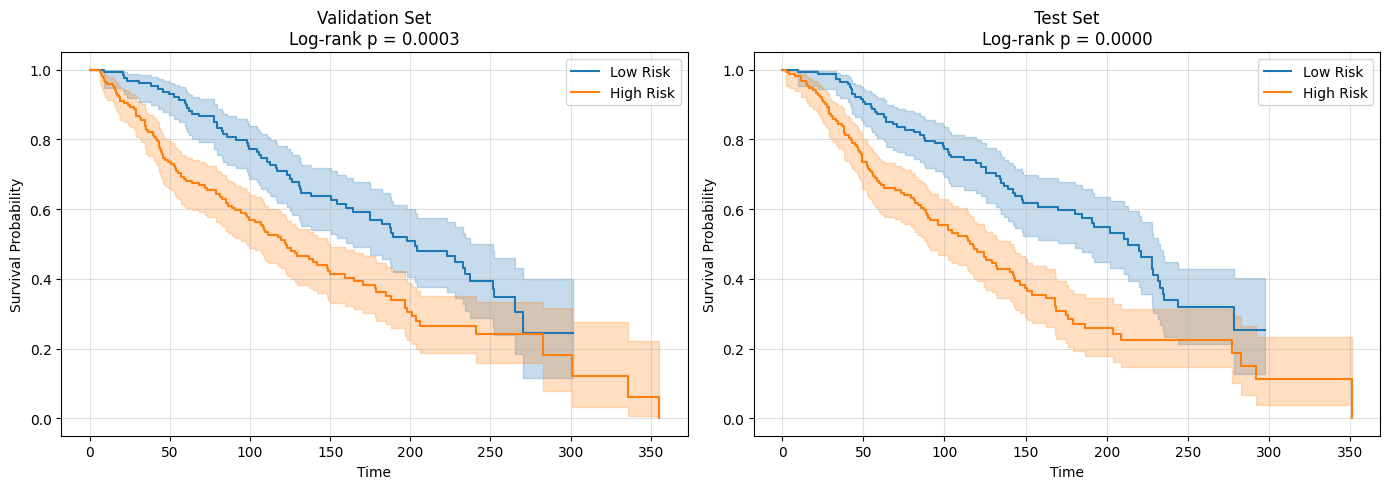

In [82]:
def plot_val_test_km(train_risk, val_df, val_risk, test_df, test_risk):

    # Use training median threshold (recommended)
    threshold = np.median(train_risk)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, df, risk, title in zip(
        axes,
        [val_df, test_df],
        [val_risk, test_risk],
        ["Validation Set", "Test Set"]
    ):

        high = risk >= threshold
        low = risk < threshold

        kmf = KaplanMeierFitter()

        # Low risk
        kmf.fit(df["time"][low], df["event"][low], label="Low Risk")
        kmf.plot(ax=ax)

        # High risk
        kmf.fit(df["time"][high], df["event"][high], label="High Risk")
        kmf.plot(ax=ax)

        # Log-rank test
        results = logrank_test(df["time"][low], df["time"][high],
            event_observed_A=df["event"][low], event_observed_B=df["event"][high])

        ax.set_title(f"{title}\nLog-rank p = {results.p_value:.4f}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Survival Probability")
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/ECEN766final/CoxPH/KM_val_test.png", dpi=300)
    plt.show()


train_risk = cph.predict_partial_hazard(train_df).values.flatten()
val_risk   = cph.predict_partial_hazard(val_df).values.flatten()
test_risk  = cph.predict_partial_hazard(test_df).values.flatten()

plot_val_test_km(train_risk, val_df, val_risk, test_df, test_risk)

In [68]:
len(coef_df[coef_df["exp(coef)"]<1])

1474

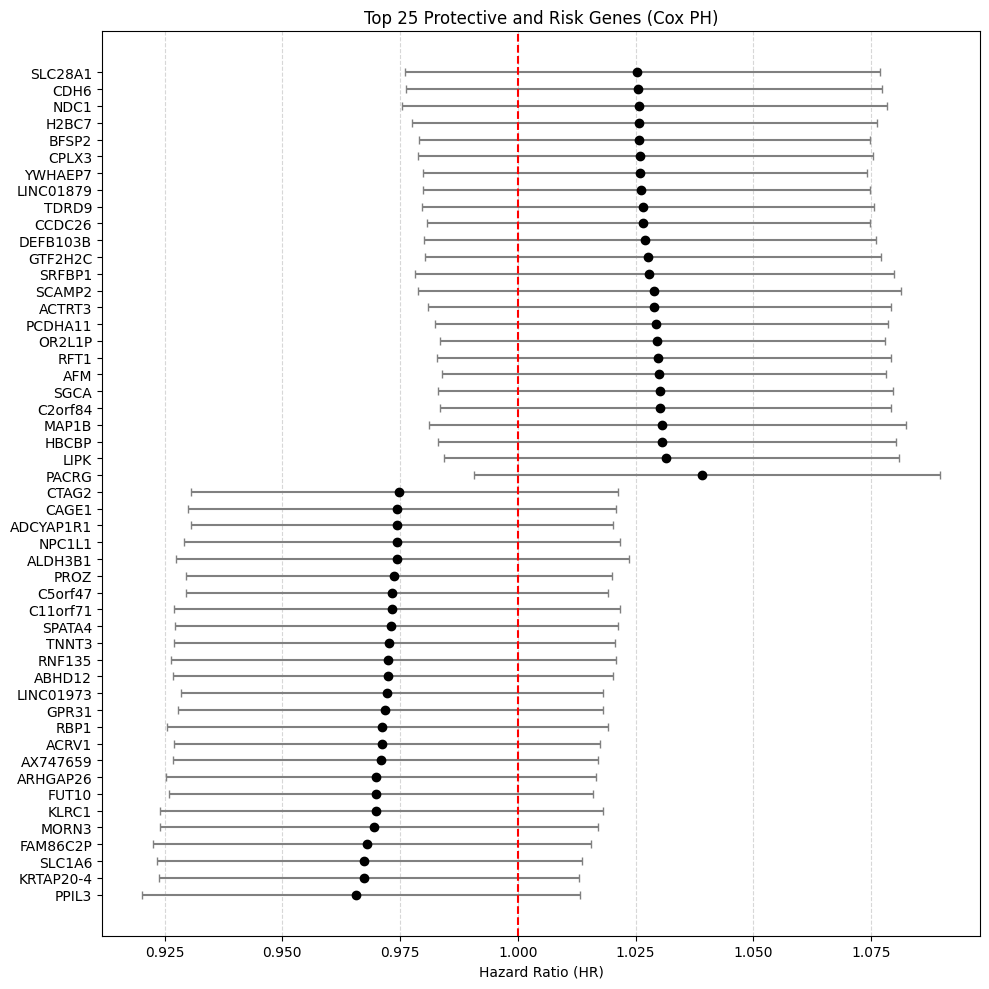

In [83]:
# Plot top 50 genes of each HR >1 and <1
def plot_balanced_forest(cph_model, top_n=10):
    summary = cph_model.summary

    # Top risk genes (HR > 1)
    top_risk = summary.sort_values("coef", ascending=False).head(top_n)

    # Top protective genes (HR < 1)
    top_protective = summary.sort_values("coef", ascending=True).head(top_n)

    # Combine
    selected = pd.concat([top_protective, top_risk])

    hr = selected["exp(coef)"]
    lower = selected["exp(coef) lower 95%"]
    upper = selected["exp(coef) upper 95%"]

    plt.figure(figsize=(10, 10))
    plt.errorbar(hr, range(len(hr)),
                 xerr=[hr - lower, upper - hr],
                 fmt='o', color='black', ecolor='gray', capsize=3)

    plt.yticks(range(len(hr)), selected.index)
    plt.axvline(x=1, color='red', linestyle='--')
    plt.xlabel("Hazard Ratio (HR)")
    plt.title(f"Top {top_n} Protective and Risk Genes (Cox PH)")
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/ECEN766final/CoxPH/Forest_plot_top25genes.png", dpi=300)
    plt.show()

# Example usage
plot_balanced_forest(cph, top_n=25)